# Lab 4

In [1]:
import numpy as np
import pandas as pd

# (1) Load the data into memory and save it to a pandas data frame. 
data = pd.read_csv("acs2017_census_tract_data.csv")
print("Data shape before dropping NA:", data.shape)

# (2) Remove any observations that having missing data. 
data.dropna(axis = 0, inplace = True)
print("Data shape after dropping NA:", data.shape)

# (3) Encode any string data as integers for now.
data['State'], _ = pd.factorize(data['State'], sort = True)
data['County'], _ = pd.factorize(data['County'], sort = True)

# 4) You have the option of keeping the "county" variable or removing it.
# Be sure to discuss why you decided to keep/remove this variable. 

# Just drop it rather than deal with multiple states with the same county name
del data['County']

# Check types
print(data.info())

Data shape before dropping NA: (74001, 37)
Data shape after dropping NA: (72718, 37)
<class 'pandas.core.frame.DataFrame'>
Index: 72718 entries, 0 to 74000
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TractId           72718 non-null  int64  
 1   State             72718 non-null  int64  
 2   TotalPop          72718 non-null  int64  
 3   Men               72718 non-null  int64  
 4   Women             72718 non-null  int64  
 5   Hispanic          72718 non-null  float64
 6   White             72718 non-null  float64
 7   Black             72718 non-null  float64
 8   Native            72718 non-null  float64
 9   Asian             72718 non-null  float64
 10  Pacific           72718 non-null  float64
 11  VotingAgeCitizen  72718 non-null  int64  
 12  Income            72718 non-null  float64
 13  IncomeErr         72718 non-null  float64
 14  IncomePerCap      72718 non-null  float64
 15  IncomeP

Here we loaded the dataset. We decided to get rid of the county data because we did not believe dealing with multiple states having the same county name was necessary, as the data is likely redundantly encoded in the tract ID.

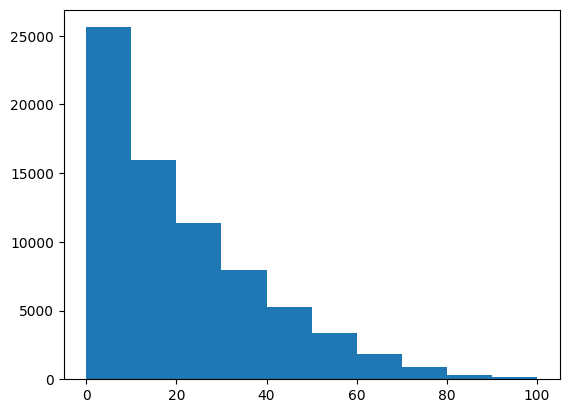

ChildPoverty
0    18229
1    18171
3    18170
2    18148
Name: count, dtype: int64
[  0.    6.2  16.3  31.6 100. ]
[[2.02000090e+09 1.00000000e+00 2.74600000e+03 ... 4.50000000e+00
  0.00000000e+00 4.80000000e+00]
 [6.08550660e+09 4.00000000e+00 7.47300000e+03 ... 5.40000000e+00
  0.00000000e+00 1.60000000e+00]
 [4.70650114e+10 4.30000000e+01 7.51800000e+03 ... 5.80000000e+00
  0.00000000e+00 6.10000000e+00]
 ...
 [3.90490032e+10 3.50000000e+01 2.78600000e+03 ... 4.30000000e+00
  0.00000000e+00 1.60000000e+00]
 [3.60470548e+10 3.20000000e+01 2.06800000e+03 ... 1.12000000e+01
  0.00000000e+00 6.60000000e+00]
 [3.70690601e+10 3.30000000e+01 4.82900000e+03 ... 9.40000000e+00
  2.20000000e+00 5.70000000e+00]]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# The next two requirements will need to be completed together
# as they might depend on one another: 

# % of children under poverty level
plt.hist(data['ChildPoverty'])
plt.show()

# Balance the dataset so that about the same number of instances are within each class.
# We perform this to training and testing for consistency.
# TODO: Is that data snooping?

target, bins = pd.qcut(data['ChildPoverty'], q = 4, labels = range(4), retbins=True)

del data['ChildPoverty']
target = target.astype('int')
print(target.value_counts())
print(bins)

# Remember: bad things happen if you use data frames!
data, target = shuffle(data, target)
X = data.to_numpy()
y = target.to_numpy()

# Split the dataset into 80% for training and 20% for testing.

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.20, shuffle = False)

print(X)

Here, we balanced the dataset and split into training and testing sets. To balance the dataset, we divided the  variable ChildPoverty into four quartiles using the pd.qcut() function. This makes sure that each poverty class contains approximately the same number of samples. We did balancing on both the training and testing set because if the test set were heavily skewed toward one class, the reported performance of our model could be misleading as the model might appear to perform better simply it predicts the majority class more often.

In [3]:
# Example adapted from https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch12/ch12.ipynb
# Original Author: Sebastian Raschka

# This is the optional book we use in the course, excellent intuitions and straightforward programming examples
# please note, however, that this code has been manipulated to reflect our assumptions and notation.
from scipy.special import expit
from sklearn.metrics import accuracy_score
import sys

# start with a simple base classifier, which can't be fit or predicted
# it only has internal classes to be used by classes that will subclass it
class TwoLayerPerceptronBase(object):
    def __init__(self, n_hidden=30,
                 C=0.0, epochs=500, eta=0.001, random_state=None):
        np.random.seed(random_state)
        self.n_hidden = n_hidden
        self.l2_C = C
        self.epochs = epochs
        self.eta = eta
        
    @staticmethod
    def _encode_labels(y):
        """Encode labels into one-hot representation"""
        onehot = pd.get_dummies(y).values.T
            
        return onehot

    def _initialize_weights(self):
        """Initialize weights with small random numbers."""
        W1_num_elems = (self.n_features_)*self.n_hidden
        W1 = np.random.uniform(-1.0, 1.0, size=W1_num_elems)
        W1 = W1.reshape(self.n_hidden, self.n_features_) # reshape to be W
        b1 = np.zeros((self.n_hidden, 1))
        
        W2_num_elems = (self.n_hidden)*self.n_output_
        W2 = np.random.uniform(-1.0, 1.0, size=W2_num_elems)
        W2 = W2.reshape(self.n_output_, self.n_hidden)
        b2 = np.zeros((self.n_output_, 1))
        
        return W1, W2, b1, b2
    
    @staticmethod
    def _sigmoid(z):
        """Use scipy.special.expit to avoid overflow"""
        # 1.0 / (1.0 + np.exp(-z))
        return expit(z)
    
    
    @staticmethod
    def _L2_reg(lambda_, W1, W2):
        """Compute L2-regularization cost"""
        # only compute for non-bias terms
        return (lambda_/2.0) * np.sqrt(np.mean(W1[:, 1:] ** 2) + np.mean(W2[:, 1:] ** 2))
    
    def _cost(self,A3,Y_enc,W1,W2):
        '''Get the objective function value'''
        cost = np.mean((Y_enc-A3)**2)
        L2_term = self._L2_reg(self.l2_C, W1, W2)
        return cost + L2_term
    
    def _feedforward(self, X, W1, W2, b1, b2):
        """Compute feedforward step
        -----------
        X : Input layer with original features.
        W1: Weight matrix for input layer -> hidden layer.
        W2: Weight matrix for hidden layer -> output layer.
        ----------
        a1-a3 : activations into layer (or output layer)
        z1-z2 : layer inputs 

        """
        A1 = X.T
        Z1 = W1 @ A1 + b1
        A2 = self._sigmoid(Z1)
        Z2 = W2 @ A2 + b2
        A3 = self._sigmoid(Z2)
        return A1, Z1, A2, Z2, A3
    
    def _get_gradient(self, A1, A2, A3, Z1, Z2, Y_enc, W1, W2):
        """ Compute gradient step using backpropagation.
        """
        # vectorized backpropagation
        V2 = -2*(Y_enc-A3)*A3*(1-A3)
        V1 = A2*(1-A2)*(W2.T @ V2)
        
        gradW2 = V2 @ A2.T
        gradW1 = V1 @ A1.T
        
        gradb2 = np.sum(V2, axis=1).reshape((-1,1))
        gradb1 = np.sum(V1, axis=1).reshape((-1,1))
        
        
        # regularize weights that are not bias terms
        gradW1 += W1 * self.l2_C
        gradW2 += W2 * self.l2_C

        return gradW1, gradW2, gradb1, gradb2
    
    def predict(self, X):
        """Predict class labels"""
        _, _, _, _, A3 = self._feedforward(X, self.W1, self.W2, self.b1, self.b2)
        y_pred = np.argmax(A3, axis=0)
        return y_pred

# just start with the vectorized version and minibatch
class TLPMiniBatch(TwoLayerPerceptronBase):
    def __init__(self, alpha=0.0, decrease_const=0.1, 
                 decrease_iter = 10, shuffle=True, 
                 minibatches=1, **kwds):        
        # need to add to the original initializer 
        self.alpha = alpha
        self.decrease_const = decrease_const
        self.decrease_iter = decrease_iter
        self.shuffle = shuffle
        self.minibatches = minibatches
        # but keep other keywords
        super().__init__(**kwds)
        
    def _momentum_update(self, eta, gradW1, gradW2, gradb1, gradb2):

        # Init momentum to zero, if first time called
        if not hasattr(self,'_rho_W1_prev'):
            # start momentum at zero for previous updates
            self._rho_W1_prev = np.zeros(self.W1.shape) # for momentum
            self._rho_W2_prev = np.zeros(self.W2.shape) # for momentum

        rho_W1, rho_W2 = eta * gradW1, eta * gradW2
        self.W1 -= (rho_W1 + (self.alpha * self._rho_W1_prev)) # update with momentum
        self.W2 -= (rho_W2 + (self.alpha * self._rho_W2_prev)) # update with momentum

        # no need for momentum in bias 
        # these values need to change abruptly and 
        # do not influence sensitivity backward
        self.b1 -= eta * gradb1
        self.b2 -= eta * gradb2

        # update previous parameters 
        # MARK: Difference from the notebook, assumed typo
        self._rho_W1_prev, self._rho_W2_prev = rho_W1, rho_W2

    def _learning_rate_update(self, epoch):
        # decrease learning rate at certain epochs
        # return an eta value
        decrease_value = self.decrease_const**(np.floor(epoch/self.decrease_iter))
        return self.eta * decrease_value

    def _update_parameters(self, eta, gradW1, gradW2, gradb1, gradb2):
        """ Compute new W and b from backpropagation.
        """
        # for now, just update with momentum parameters 
        self._momentum_update(eta, gradW1, gradW2, gradb1, gradb2)
        
    
    def fit(self, X, y, print_progress=False, XY_test=None):
        """ Learn weights from training data. With mini-batch"""
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)
        
        # init weights and setup matrices
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]

        if not hasattr(self,'W1'):
            # Init Weights if first time called fit 
            self.W1, self.W2, self.b1, self.b2 = self._initialize_weights()

        self.cost_ = []
        self.score_ = []
        # get starting acc
        self.score_.append(accuracy_score(y_data,self.predict(X_data)))
        
        # keep track of validation, if given
        if XY_test is not None:
            X_test = XY_test[0].copy()
            y_test = XY_test[1].copy()
            self.val_score_ = []
            self.val_score_.append(accuracy_score(y_test,self.predict(X_test)))
            self.val_cost_ = []
            
        for i in range(self.epochs):

            # adaptive learning rate
            eta = self._learning_rate_update(i)

            if print_progress>0 and (i+1)%print_progress==0:
                sys.stderr.write('\rEpoch: %d/%d' % (i+1, self.epochs))
                sys.stderr.flush()

            if self.shuffle:
                idx_shuffle = np.random.permutation(y_data.shape[0])
                X_data, Y_enc, y_data = X_data[idx_shuffle], Y_enc[:, idx_shuffle], y_data[idx_shuffle]

            mini = np.array_split(range(y_data.shape[0]), self.minibatches)
            mini_cost = []
            for idx in mini:

                # feedforward
                A1, Z1, A2, Z2, A3 = self._feedforward(X_data[idx],
                                                       self.W1, self.W2,
                                                       self.b1, self.b2
                                                      )
                
                cost = self._cost(A3,Y_enc[:, idx],self.W1,self.W2)
                mini_cost.append(cost) # this appends cost of mini-batch only

                # compute gradient via backpropagation
                gradW1, gradW2, gradb1, gradb2 = self._get_gradient(A1=A1, A2=A2, A3=A3, Z1=Z1, Z2=Z2, 
                                                  Y_enc=Y_enc[:, idx],
                                                  W1=self.W1,W2=self.W2)
                
                # Updates all W and b values in self
                self._update_parameters(eta, gradW1, gradW2, gradb1, gradb2)
                

            self.cost_.append(np.mean(mini_cost))
            self.score_.append(accuracy_score(y_data,self.predict(X_data)))
            
            # update if a validation set was provided
            if XY_test is not None:
                yhat = self.predict(X_test)
                self.val_score_.append(accuracy_score(y_test,yhat))
            
        return self

# to implement the new style of objective function, 
# we just need to update the final layer calculation of the gradient
class TLPMiniBatchCrossEntropy(TLPMiniBatch):
    def _cost(self,A3,Y_enc,W1,W2):
        '''Get the objective function value'''
        cost = -np.mean(np.nan_to_num((Y_enc*np.log(A3+1e-7)+(1-Y_enc)*np.log(1-A3+1e-7))))
        L2_term = self._L2_reg(self.l2_C, W1, W2)
        return cost + L2_term
    
    def _get_gradient(self, A1, A2, A3, Z1, Z2, Y_enc, W1, W2):
        """ Compute gradient step using backpropagation.
        """
        # vectorized backpropagation
        V2 = (A3-Y_enc) # <- this is only line that changed
        V1 = A2*(1-A2)*(W2.T @ V2)
        
        gradW2 = V2 @ A2.T
        gradW1 = V1 @ A1.T
        
        gradb2 = np.sum(V2, axis=1).reshape((-1,1))
        gradb1 = np.sum(V1, axis=1).reshape((-1,1))
        
        # regularize weights that are not bias terms
        gradW1 += W1 * self.l2_C
        gradW2 += W2 * self.l2_C

        return gradW1, gradW2, gradb1, gradb2
        
class TLPBetterInitial(TLPMiniBatchCrossEntropy):             
    def _initialize_weights(self):
        """Initialize weights Glorot and He normalization."""
        init_bound = 4*np.sqrt(6. / (self.n_hidden + self.n_features_))
        W1 = np.random.uniform(-init_bound, init_bound,(self.n_hidden, self.n_features_))

        # reduce the final layer magnitude in order to balance the size of the gradients
        # between 
        init_bound = 4*np.sqrt(6 / (self.n_output_ + self.n_hidden))
        W2 = np.random.uniform(-init_bound, init_bound,(self.n_output_, self.n_hidden)) 
        
        # set these to zero to start so that
        # they do not immediately saturate the neurons
        b1 = np.zeros((self.n_hidden, 1))
        b2 = np.zeros((self.n_output_, 1))-2.0 #ensure stays about zero mean
        
        return W1, W2, b1, b2

This code is provided from Dr. Larson's sample notebook, and creates a two-layer perceptron with vectorized backpropagation, mini-batching, cross-entropy loss, and improved weight initialization. `_get_gradient` handles vectorized gradient computation, `TLPMiniBatch` adds mini-batching, `TLPMiniBatchCrossEntropy` replaces MSE with cross-entropy loss, and `TLPBetterInitial` uses Glorot initialization.

In [4]:
from sklearn.metrics import confusion_matrix
%matplotlib inline

plt.style.use('ggplot')

def print_result(nn,X_train,y_train,X_test,y_test,title="",color="red"):
    
    print("=================")
    print("%s:" % title)
    yhat = nn.predict(X_train)
    print('Resubstitution acc:', accuracy_score(y_train,yhat))
    
    yhat = nn.predict(X_test)
    print('Validation acc:', accuracy_score(y_test,yhat))
    print('Validation confusion matrix:\n', confusion_matrix(y_test, yhat))
    
    if hasattr(nn,'val_score_'):
        plt.plot(range(len(nn.val_score_)), nn.val_score_, color=color,label=title)
        plt.ylabel('Validation Accuracy')
    else:
        plt.plot(range(len(nn.score_)), nn.score_, color=color,label=title)
        plt.ylabel('Resub Accuracy')
        
    plt.xlabel('Epochs')
    plt.tight_layout()
    plt.legend(loc='best')
    plt.grid(True)

    return yhat

Epoch: 30/30

CPU times: user 1.55 s, sys: 257 ms, total: 1.81 s
Wall time: 1.8 s
Initial:
Resubstitution acc: 0.25107436311754394
Validation acc: 0.24511826182618263
Validation confusion matrix:
 [[   0 3662    0    0]
 [   0 3565    0    0]
 [   0 3705    0    0]
 [   0 3612    0    0]]


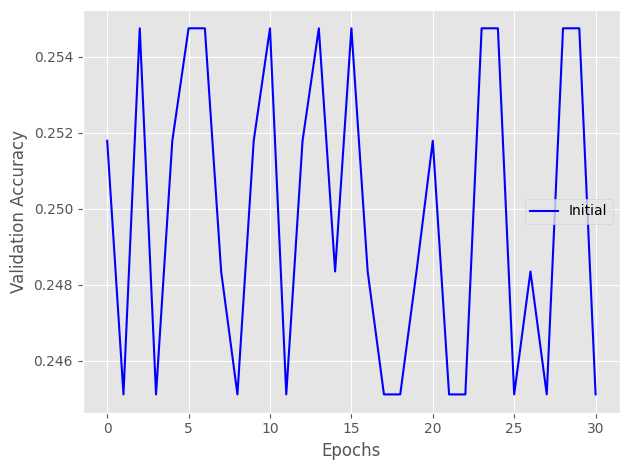

In [5]:
# Quantify performance using accuracy.

vals = { 'n_hidden':30, 
         'C':0.1, 'epochs':30, 'eta':0.001,
         'alpha':0.001, 'decrease_const':0.1, 'decrease_iter':15,
         'minibatches':50,
         'shuffle':True,'random_state':1}

nn_better = TLPBetterInitial(**vals)

%time nn_better.fit(X_train, y_train, print_progress=1, XY_test=(X_test, y_test))
yhat1 = print_result(nn_better,X_train,y_train,X_test,y_test,title="Initial",color="blue")
plt.show()

Here, we successfully quantified performance using accuracy, and outputted the accuracy scores resubstitution and validation. We also graphed the loss function versus the number of epochs and see that before normalizing the continuous numeric feature data or applied one-hot encoding the accuracy is not good, and ended around 0.244 or just under 25%. The training also does not seem to converge around any specific point. Furthermore, the confusion matrix shows that the classifier is classifying all samples as the same class, and there are 4 roughly evenly divided classes, which is why the performance is roughly 25%.

Epoch: 30/30

CPU times: user 2.43 s, sys: 239 ms, total: 2.67 s
Wall time: 2.66 s
Normalized:
Resubstitution acc: 0.7241723106542441
Validation acc: 0.7223597359735974
Validation confusion matrix:
 [[2921  587   98   56]
 [ 828 2031  650   56]
 [  55  644 2459  547]
 [  13   13  491 3095]]


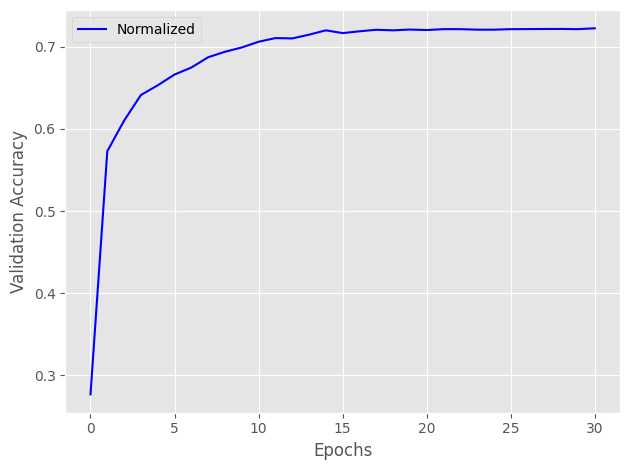

In [6]:
# Now (1) normalize the continuous numeric feature data.
# TODO: Is it acceptable to normalize all feature data?

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train, y_train)
X_test = scaler.transform(X_test)

%time nn_better.fit(X_train, y_train, print_progress=1, XY_test=(X_test, y_test))
yhat2 = print_result(nn_better,X_train,y_train,X_test,y_test,title="Normalized",color="blue")
plt.show()

Here, we added normalization of the continuous numeric feature data and saw an immediate improvement. The validation accuracy now converges around 0.72, which is much better than the initial 0.244.

Epoch: 30/30

CPU times: user 2.97 s, sys: 344 ms, total: 3.31 s
Wall time: 3.31 s
Normalized:
Resubstitution acc: 0.7154226974249664
Validation acc: 0.7097772277227723
Validation confusion matrix:
 [[2951  539  107   65]
 [ 939 1871  704   51]
 [ 101  600 2448  556]
 [  14   14  531 3053]]


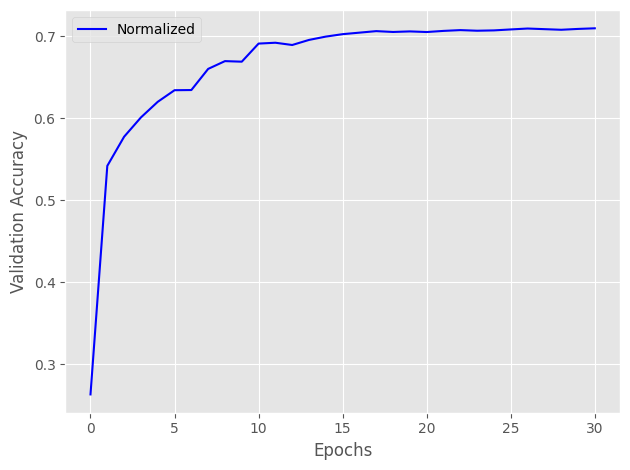

In [7]:
# Now (1) normalize the continuous numeric feature data
# AND (2) one hot encode the categorical feature data.

# One hot encode by modifying the original dataframe
out = pd.get_dummies(data, columns = ['State'])
X = out.to_numpy()

# Once again, split the dataset into 80% for training and 20% for testing.
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.20, shuffle = False)

# Once again, normalize it
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train, y_train)
X_test = scaler.transform(X_test)

# Reinitialize the network to prevent pollution
vals = { 'n_hidden':30, 
         'C':0.1, 'epochs':30, 'eta':0.001,
         'alpha':0.001, 'decrease_const':0.1, 'decrease_iter':15,
         'minibatches':50,
         'shuffle':True,'random_state':1}
nn_better2 = TLPBetterInitial(**vals)

%time nn_better2.fit(X_train, y_train, print_progress=1, XY_test=(X_test, y_test))
yhat3 = print_result(nn_better2,X_train,y_train,X_test,y_test,title="Normalized",color="blue")
plt.show()

Here, we applied both the normalization and one-hot encoding to the model. The accuracy now converges around 0.71, which is lower than the testing done without one-hot encoding, which I did not expect.

In [8]:
# Compare the performance of the three models you just trained.
# Use McNemar's test from the flipped video!

from itertools import combinations
from scipy import stats

# Survival function (1 - cdf): yields p-value from test statistic
# For instance, 3.841 would yield p = 0.05
chi2_p_value = stats.chi2.sf

def mcnemar_table(y_target, y_model1, y_model2):
    table = np.zeros((2, 2))
    for y, yhat1, yhat2 in zip(y_target, y_model1, y_model2):
        index1 = (1 if yhat1 == y else 0)
        index2 = (1 if yhat2 == y else 0)
        table[index1, index2] += 1
    return table

def mcnemar(table, corrected = True, exact = False):
    if exact:
        print("Warning: Exact test not implemented")

    b = table[0, 1]
    c = table[1, 0]
    if corrected:
        # Continuity correction from Edwards (1948)
        chi2 = ((abs(b - c) - 1) ** 2) / (b + c)
    else:
        # Original test statistic
        chi2 = ((b - c) ** 2) / (b + c)
    p = chi2_p_value(chi2, df = 1)
    return chi2, p

def mcnemar_test(y_target, model1, model2):
    table = mcnemar_table(y_target = y_test, y_model1 = model1, y_model2 = model2)
    print(table)
    n = table[0, 1] + table[1, 0]
    return mcnemar(table, corrected = True, exact = n < 25)

def test_models(y_test, alpha, models, names):
    for a, b in combinations(range(len(models)), 2):
        model1, name1, model2, name2 = (models[a], names[a], models[b], names[b])
        chi2, p = mcnemar_test(y_test, model1, model2)
        print("\u03c7\u00b2 = %0.4f, p = %0.10f for %s and %s so result is%s significantly different" %
            (chi2, p, name1, name2, "n't" if p > alpha else ""))

test_models(y_test, 0.05, [yhat1, yhat2, yhat3],
    ["Non-normalized Glorot", "Normalized Glorot", "Encoded Glorot"])

[[2504. 8475.]
 [1534. 2031.]]
χ² = 4812.0292, p = 0.0000000000 for Non-normalized Glorot and Normalized Glorot so result is significantly different
[[2527. 8452.]
 [1694. 1871.]]
χ² = 4500.0048, p = 0.0000000000 for Non-normalized Glorot and Encoded Glorot so result is significantly different
[[3499.  539.]
 [ 722. 9784.]]
χ² = 26.2680, p = 0.0000002972 for Normalized Glorot and Encoded Glorot so result is significantly different


We use McNemar's test with Edwards continuity correction to compare performance between two models.

We then use the survival function (that is, 1 minus the cumulative distribution function) of the $\chi^2$ distribution with 1 degree of freedom to calculate a p-value. Although we use a significance level of $\alpha = 0.05$ and could thus simply compare the $\chi^2$ test statistic with the critical value 3.841 obtained from a table, the p-value can be used to more easily interpret the significance level of the result.

In all three cases, the p-value is smaller than 0.05, so we reject the null hypothesis, and conclude that the models have significantly different performance.

In [9]:
# Generalize the above to N layers
class NLayerPerceptronBase(object):
    def __init__(self, n_hidden = [30, 30],
                 C=0.0, epochs=500, eta=0.001, random_state=None):
        np.random.seed(random_state)
        self.n_hidden = [n_hidden] if type(n_hidden) is int else n_hidden
        self.num_layers = len(self.n_hidden) + 1
        self.l2_C = C
        self.epochs = epochs
        self.eta = eta
        
    @staticmethod
    def _encode_labels(y):
        """Encode labels into one-hot representation"""
        onehot = pd.get_dummies(y).values.T
            
        return onehot

    def _initialize_weights(self):
        """Initialize weights with small random numbers."""

        n_hidden = self.n_hidden + [self.n_output_]
        n_hidden_last = [self.n_features_] + self.n_hidden

        W = [None] * (self.num_layers)
        b = [None] * (self.num_layers)

        for i in range(self.num_layers):
            Wi_num_elems = (n_hidden_last[i]) * n_hidden[i]
            Wi = np.random.uniform(-1.0, 1.0, size=Wi_num_elems)
            W[i] = Wi.reshape(n_hidden[i], n_hidden_last[i]) # reshape to be W
            b[i] = np.zeros((n_hidden[i], 1))
        
        return W, b
    
    @staticmethod
    def _sigmoid(z):
        """Use scipy.special.expit to avoid overflow"""
        # 1.0 / (1.0 + np.exp(-z))
        return expit(z)
    
    @staticmethod
    def _L2_reg(lambda_, W):
        """Compute L2-regularization cost"""
        # only compute for non-bias terms

        return (lambda_/2.0) * np.sqrt(np.sum(np.array([np.mean(Wi[:, 1:] ** 2) for Wi in W])))
    
    def _cost(self, A_last, Y_enc, W):
        '''Get the objective function value'''
        cost = np.mean((Y_enc - A_last)**2)
        L2_term = self._L2_reg(self.l2_C, W)
        return cost + L2_term
    
    def _feedforward(self, X, W, b):
        """Compute feedforward step
        -----------
        X: Input layer with original features.
        W: Weight matrices: matrix i for hidden layer i - 1 --> hidden layer i.
        ----------
        a : activations into layer (or output layer)
        z : layer inputs 

        """

        A = [None] * (self.num_layers + 1)
        Z = [None] * (self.num_layers)

        A[0] = X.T
        for i in range(self.num_layers):
            Z[i] = W[i] @ A[i] + b[i]
            A[i + 1] = self._sigmoid(Z[i])

        return A, Z
    
    def _get_gradient(self, A, Z, Y_enc, W):
        """ Compute gradient step using backpropagation.
        """
        # vectorized backpropagation
        V = [None] * (self.num_layers)
        V[-1] = -2 * (Y_enc - A[-1]) * A[-1] * (1 - A[-1])
        for i in reversed(range(self.num_layers - 1)):
            V[i] = A[i + 1] * (1 - A[i + 1]) * (W[i + 1].T @ V[i + 1])
        
        gradW = [None] * (self.num_layers)
        gradb = [None] * (self.num_layers)
        for i in range(self.num_layers):
            gradW[i] = V[i] @ A[i].T
            gradb[i] = np.sum(V[i], axis=1).reshape((-1,1))
            # regularize weights that are not bias terms
            gradW[i] += W[i] * self.l2_C
        
        return gradW, gradb
    
    def predict(self, X):
        """Predict class labels"""
        A, _ = self._feedforward(X, self.W, self.b)
        y_pred = np.argmax(A[-1], axis=0)
        return y_pred

# just start with the vectorized version and minibatch
class NLPMiniBatch(NLayerPerceptronBase):
    def __init__(self, alpha=0.0, decrease_const=0.1, 
                 decrease_iter = 10, shuffle=True, 
                 minibatches=1, **kwds):        
        # need to add to the original initializer 
        self.alpha = alpha
        self.decrease_const = decrease_const
        self.decrease_iter = decrease_iter
        self.shuffle = shuffle
        self.minibatches = minibatches
        # but keep other keywords
        super().__init__(**kwds)
        
    def _momentum_update(self, eta, gradW, gradb):

        # Init momentum to zero, if first time called
        if not hasattr(self,'_rho_W_prev'):
            # start momentum at zero for previous updates
            self._rho_W_prev = [None] * (self.num_layers)
            for i in range(self.num_layers):
                self._rho_W_prev[i] = np.zeros(self.W[i].shape) # for momentum
            
        for i in range(self.num_layers):
            rho_Wi = eta * gradW[i]
            self.W[i] -= (rho_Wi + (self.alpha * self._rho_W_prev[i])) # update with momentum

            # no need for momentum in bias 
            # these values need to change abruptly and 
            # do not influence sensitivity backward
            self.b[i] -= eta * gradb[i]

            # MARK: Difference from the notebook, assumed typo
            self._rho_W_prev[i] = rho_Wi

    def _learning_rate_update(self, epoch):
        # decrease learning rate at certain epochs
        # return an eta value
        decrease_value = self.decrease_const**(np.floor(epoch/self.decrease_iter))
        return self.eta * decrease_value

    def _update_parameters(self, eta, gradW, gradb):
        """ Compute new W and b from backpropagation.
        """
        # for now, just update with momentum parameters 
        self._momentum_update(eta, gradW, gradb)
        
    
    def fit(self, X, y, print_progress=False, XY_test=None):
        """ Learn weights from training data. With mini-batch"""
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)
        
        # init weights and setup matrices
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]

        if not hasattr(self, 'W'):
            # Init Weights if first time called fit 
            self.W, self.b = self._initialize_weights()

        self.cost_ = []
        self.score_ = []
        # get starting acc
        self.score_.append(accuracy_score(y_data, self.predict(X_data)))
        
        # keep track of validation, if given
        if XY_test is not None:
            X_test = XY_test[0].copy()
            y_test = XY_test[1].copy()
            self.val_score_ = []
            self.val_score_.append(accuracy_score(y_test, self.predict(X_test)))
            self.val_cost_ = []
            
        self.grad_w_ = np.ndarray((self.epochs, self.num_layers))
        for i in range(self.epochs):
            # adaptive learning rate
            eta = self._learning_rate_update(i)

            if print_progress > 0 and (i + 1) % print_progress == 0:
                sys.stderr.write('\rEpoch: %d/%d' % (i + 1, self.epochs))
                sys.stderr.flush()

            if self.shuffle:
                idx_shuffle = np.random.permutation(y_data.shape[0])
                X_data, Y_enc, y_data = X_data[idx_shuffle], Y_enc[:, idx_shuffle], y_data[idx_shuffle]

            mini = np.array_split(range(y_data.shape[0]), self.minibatches)
            mini_cost = []
            for idx in mini:
                # feedforward
                A, Z = self._feedforward(X_data[idx], self.W, self.b)
                
                cost = self._cost(A[-1], Y_enc[:, idx], self.W)
                mini_cost.append(cost) # this appends cost of mini-batch only

                # compute gradient via backpropagation
                gradW, gradb = self._get_gradient(A = A, Z = Z, 
                                                  Y_enc = Y_enc[:, idx],
                                                  W = self.W)
                
                # Updates all W and b values in self
                self._update_parameters(eta, gradW, gradb)

                # MARK: Add support to track the magnitude of the gradient
                for j in range(self.num_layers):
                    self.grad_w_[i, j] = np.mean(np.abs(gradW[j]))

            self.cost_.append(np.mean(mini_cost))
            self.score_.append(accuracy_score(y_data, self.predict(X_data)))
            
            # update if a validation set was provided
            if XY_test is not None:
                yhat = self.predict(X_test)
                self.val_score_.append(accuracy_score(y_test, yhat))
            
        return self
    
    # to implement the new style of objective function, 
# we just need to update the final layer calculation of the gradient
class NLPMiniBatchCrossEntropy(NLPMiniBatch):
    def _cost(self, A_last, Y_enc, W):
        '''Get the objective function value'''
        cost = -np.mean(np.nan_to_num((Y_enc * np.log(A_last + 1e-7) + (1 - Y_enc) * np.log(1 - A_last + 1e-7))))
        L2_term = self._L2_reg(self.l2_C, W)
        return cost + L2_term
    
    def _get_gradient(self, A, Z, Y_enc, W):
        """ Compute gradient step using backpropagation.
        """
        # vectorized backpropagation
        V = [None] * (self.num_layers)
        V[-1] = (A[-1] - Y_enc) # <- this is only line that changed
        for i in reversed(range(self.num_layers - 1)):
            V[i] = A[i + 1] * (1 - A[i + 1]) * (W[i + 1].T @ V[i + 1])
        
        gradW = [None] * (self.num_layers)
        gradb = [None] * (self.num_layers)
        for i in range(self.num_layers):
            gradW[i] = V[i] @ A[i].T
            gradb[i] = np.sum(V[i], axis=1).reshape((-1,1))
            # regularize weights that are not bias terms
            gradW[i] += W[i] * self.l2_C
        
        return gradW, gradb
        
class NLPBetterInitial(NLPMiniBatchCrossEntropy):             
    def _initialize_weights(self):
        """Initialize weights Glorot and He normalization."""

        n_hidden = self.n_hidden + [self.n_output_]
        n_hidden_last = [self.n_features_] + self.n_hidden

        W = [None] * (self.num_layers)
        b = [None] * (self.num_layers)

        # reduce the final layer magnitude in order to balance the size of the gradients
        # between
        for i in range(self.num_layers):
            init_bound = 4 * np.sqrt(6.0 / (n_hidden[i] + n_hidden_last[i]))
            W[i] = np.random.uniform(-init_bound, init_bound, (n_hidden[i], n_hidden_last[i]))

            # set these to zero to start so that
            # they do not immediately saturate the neurons
            b[i] = np.zeros((n_hidden[i], 1))
                
        return W, b

# just need to optimize the fit function such that we use 
# the G value above
class NLPAdaGrad(NLPBetterInitial):
    def _ada_grad_update(self, gradW):
        if not hasattr(self, '_G_prev'):
            # adaptive G for entire gradient
            self._G_prev = [None] * (self.num_layers)
            for i in range(self.num_layers):
                self._G_prev[i] = np.zeros(self.W[i].shape) # for adaptive

        # Eta-grad implementation:
        for i in range(self.num_layers):
            # G_i = alpha * G_(i - 1) + grad @ grad
            # grad = grad @ 1 / sqrt(G_i + epsilon)
            Gi = gradW[i] * gradW[i] + self.alpha * self._G_prev[i] + 1e-7
            gradW[i] /= np.sqrt(Gi)
            # save previous updates (momentum in G)
            self._G_prev[i] = Gi

        return gradW

    def _update_parameters(self, eta, gradW, gradb):
        # adagrad
        gradW = self._ada_grad_update(gradW)
        # simple momentum 
        self._momentum_update(eta, gradW, gradb)

class NLPRMSProp(NLPAdaGrad):
    def _rms_prop_update(self, gradW):
        if not hasattr(self, '_V_prev'):
            # adaptive V for entire gradient
            self._V_prev = [None] * (self.num_layers)
            for i in range(self.num_layers):
                self._V_prev[i] = np.zeros(gradW[i].shape) # for adaptive

        # Eta-grad implementation:
        for i in range(self.num_layers):
            # V_i = alpha * V_(i - 1) + (1 - alpha) * grad * grad
            # grad = grad * 1 / sqrt(V_i + epsilon)
            Vi = self.alpha * self._V_prev[i] + (1 - self.alpha) * gradW[i] * gradW[i]
            gradW[i] /= np.sqrt(Vi + 1e-7)

            # save previous updates (momentum in G)
            self._V_prev[i] = Vi

        return gradW

    def _update_parameters(self, eta, gradW, gradb):
        # adagrad
        gradW = self._rms_prop_update(gradW)
        # simple momentum 
        self._momentum_update(eta, gradW, gradb)

Here we modified the prior two layer perceptron code to support any $n \ge 2$ number of layers. It still supports the same features including vectorized backpropagation, mini-batching, cross-entropy loss, and improved weight initialization. We also implement the adaptive methods AdaGrad and RMSProp here for later convenience.

Epoch: 30/30

CPU times: user 3 s, sys: 336 ms, total: 3.33 s
Wall time: 3.34 s


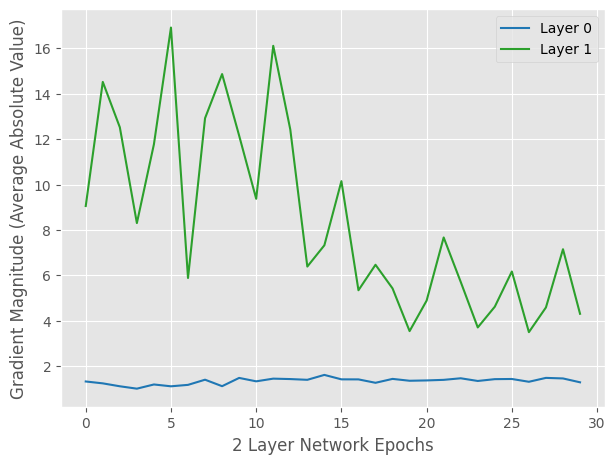

Epoch: 30/30

CPU times: user 4.16 s, sys: 527 ms, total: 4.68 s
Wall time: 4.68 s


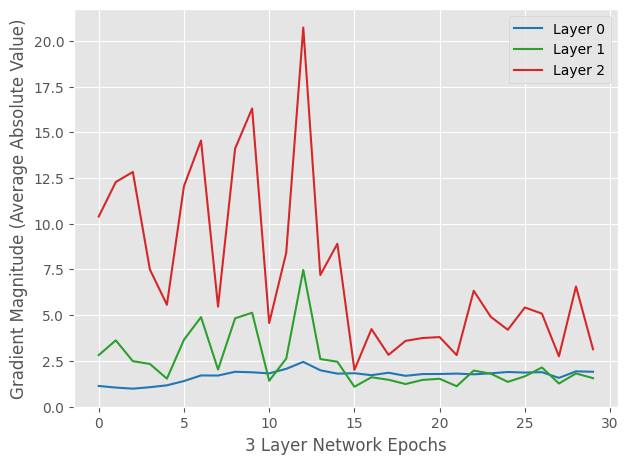

Epoch: 30/30

CPU times: user 5.38 s, sys: 711 ms, total: 6.09 s
Wall time: 6.13 s


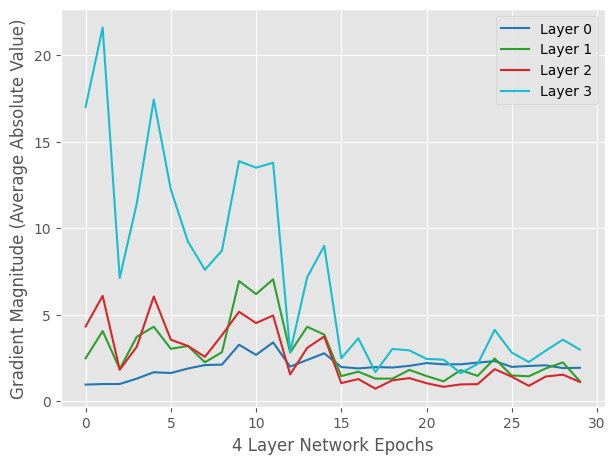

Epoch: 30/30

CPU times: user 6.67 s, sys: 1.04 s, total: 7.7 s
Wall time: 7.79 s


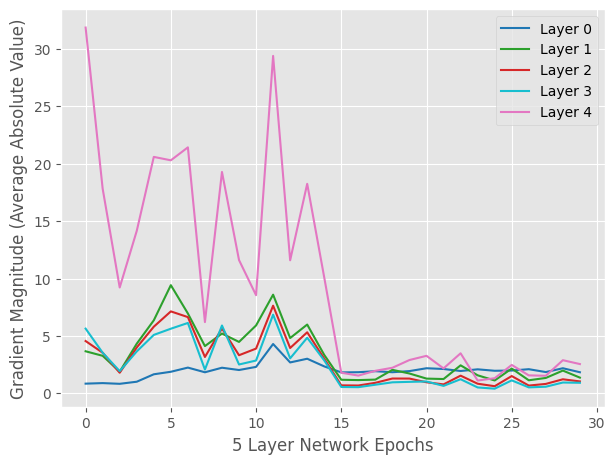

Epoch: 30/30

CPU times: user 7.78 s, sys: 1.23 s, total: 9.01 s
Wall time: 9.02 s


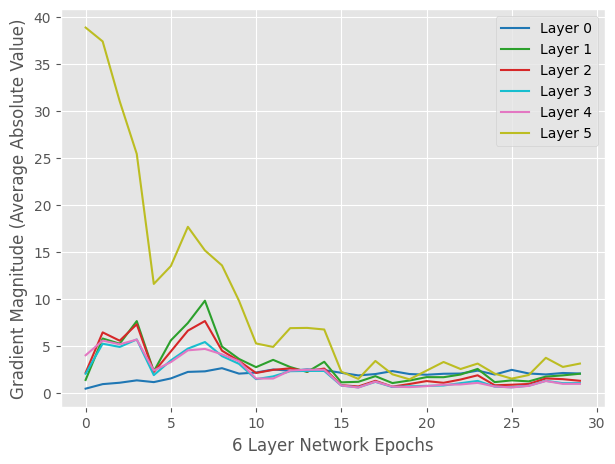

Epoch: 30/30

CPU times: user 9.09 s, sys: 1.59 s, total: 10.7 s
Wall time: 10.7 s


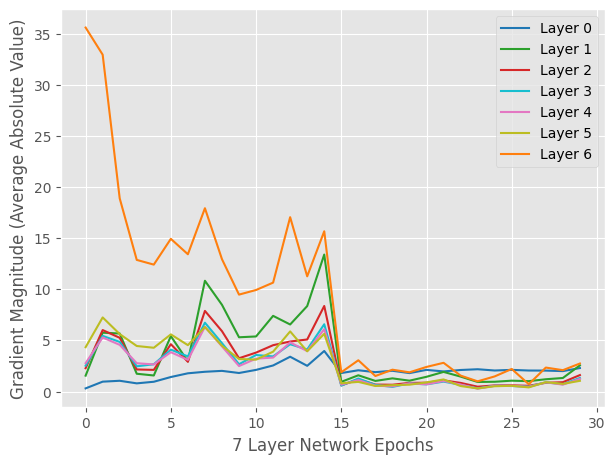

Epoch: 30/30

CPU times: user 10.3 s, sys: 2.11 s, total: 12.4 s
Wall time: 12.4 s


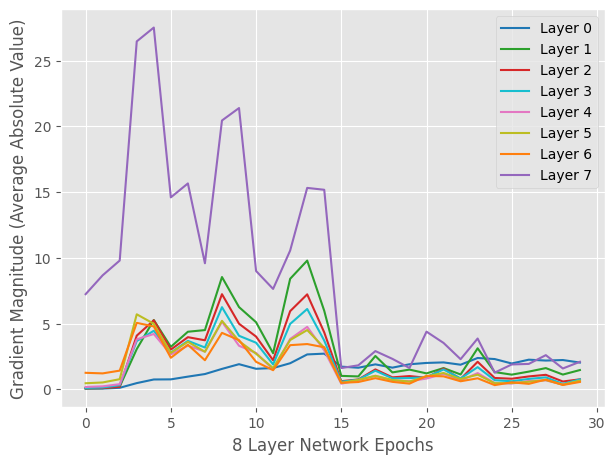

Epoch: 30/30

CPU times: user 11.6 s, sys: 2.56 s, total: 14.1 s
Wall time: 14.2 s


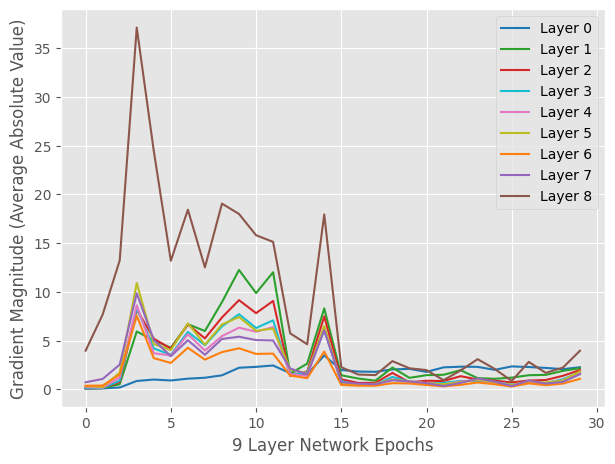

Epoch: 30/30

CPU times: user 12.2 s, sys: 2.8 s, total: 15 s
Wall time: 15.1 s


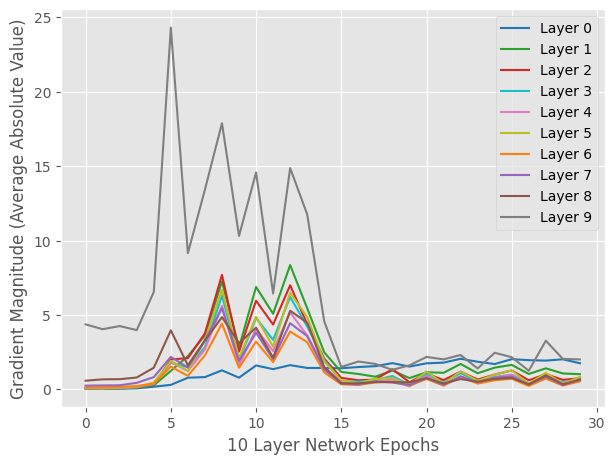

Glorot Initial 2 layers:
Resubstitution acc: 0.7146835356000962
Validation acc: 0.7088146314631463
Validation confusion matrix:
 [[2944  551  101   66]
 [ 945 1882  688   50]
 [ 101  611 2430  563]
 [  13   15  531 3053]]
Glorot Initial 3 layers:
Resubstitution acc: 0.7285041427441813
Validation acc: 0.7218784378437844
Validation confusion matrix:
 [[2781  734   87   60]
 [ 682 2184  649   50]
 [  49  627 2498  531]
 [  15   11  550 3036]]
Glorot Initial 4 layers:
Resubstitution acc: 0.7317186371918727
Validation acc: 0.7244224422442245
Validation confusion matrix:
 [[2770  720  116   56]
 [ 648 2158  705   54]
 [  41  591 2514  559]
 [  11    8  499 3094]]
Glorot Initial 5 layers:
Resubstitution acc: 0.7313576511843779
Validation acc: 0.7253850385038504
Validation confusion matrix:
 [[2747  727  130   58]
 [ 648 2196  666   55]
 [  31  589 2540  545]
 [   5   14  526 3067]]
Glorot Initial 6 layers:
Resubstitution acc: 0.7302231237322515
Validation acc: 0.7213283828382838
Validation co

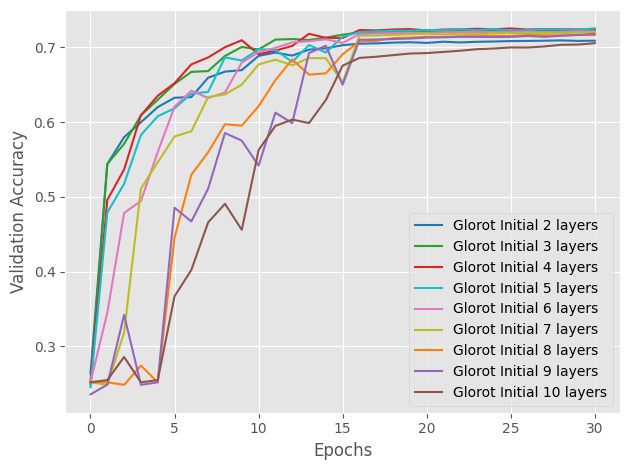

In [10]:
# Now use more layers!

colors = ['tab:blue', 'tab:green', 'tab:red',
        'tab:cyan', 'tab:pink', 'tab:olive',
        'tab:orange', 'tab:purple', 'tab:brown',
        'tab:gray']

def plot_gradient_magnitude(epoch_gradient_weights, name):
    plt.figure()
    plt.ylabel('Gradient Magnitude (Average Absolute Value)')
    plt.xlabel("%s Epochs" % name)
    plt.tight_layout()
    plt.grid(True)
    assert(layer_count <= len(colors))

    for i in range(layer_count):
        grad_layer = epoch_gradient_weights[:, i]
        plt.plot(range(len(grad_layer)), grad_layer, color=colors[i], label="Layer %d" % i)

    plt.legend(loc='best')


# This is only required to be 3-5 but it might help with comparative analysis
min_layers = 2
max_layers = 10
test_networks = []
for layer_count in range(min_layers, max_layers + 1):
    hidden_layer_count = layer_count - 1
    vals = { 'n_hidden':[30] * hidden_layer_count, 
            'C':0.1, 'epochs':30, 'eta':0.001,
            'alpha':0.001, 'decrease_const':0.1, 'decrease_iter':15,
            'minibatches':50,
            'shuffle':True,'random_state':1}

    test_network = NLPBetterInitial(**vals)
    %time test_network.fit(X_train, y_train, print_progress=1, XY_test=(X_test, y_test))
    # Plot average magnitude of the gradient for each layer 
    plot_gradient_magnitude(test_network.grad_w_, "%d Layer Network" % layer_count)
    plt.show()
    test_networks.append((layer_count, test_network))
    
for i, (layer_count, network) in enumerate(test_networks):
    print_result(network,X_train,y_train,X_test,y_test,title="Glorot Initial %d layers" % layer_count,color=colors[i])
plt.show()

Here, we did the same thing as for the two-layer perceptron and Quantified the performance of the model and graphed the magnitudes for each layer versus the number of epochs.

The assignment only asked us to graph the magnitudes of the gradient for each layer for five layers, but we decided to do ten because our implementation allowed it and we wanted to investigate slightly reduced accuracy we observed with 5 layers. For layers 1-5, the magnitude started slightly higher and consistently decreased towards more normal levels, but after those levels the magnitudes began acting more volatile, starting at a much higher level than before and sharply decreasing down. The graphs also showed weird patterns of sharply rising and falling at random variables, showing the model became less consistent as the level of layers increased. This is shown in the graphical representation of the quantified accuracy where the highest accuracy was actually in level four with an accuracy of 0.7244 (note that the last places differ across runs). The accuracy of the perceptron steadily decreased each layer after that.

This performance suggests that higher numbers of layers may result in oversaturation of neurons that prevent the network from training quickly enough, but it may also mean that fine-tuning the number of neurons per layer is necessary.

Epoch: 30/30

CPU times: user 6.55 s, sys: 1.2 s, total: 7.74 s
Wall time: 7.74 s
Glorot Initial:
Resubstitution acc: 0.7313576511843779
Validation acc: 0.7253850385038504
Validation confusion matrix:
 [[2747  727  130   58]
 [ 648 2196  666   55]
 [  31  589 2540  545]
 [   5   14  526 3067]]


Epoch: 30/30

CPU times: user 11.3 s, sys: 1.94 s, total: 13.2 s
Wall time: 13.3 s
Adagrad 5 layers:
Resubstitution acc: 0.7475676419018805
Validation acc: 0.7321232123212321
Validation confusion matrix:
 [[2772  768   87   35]
 [ 595 2237  688   45]
 [  61  567 2549  528]
 [  20   14  488 3090]]


Epoch: 30/30

CPU times: user 11.1 s, sys: 1.8 s, total: 12.9 s
Wall time: 12.9 s
RMSProp 5 layers:
Resubstitution acc: 0.7462096469213051
Validation acc: 0.7313668866886689
Validation confusion matrix:
 [[2761  781   72   48]
 [ 581 2297  634   53]
 [  70  601 2414  620]
 [  25   10  412 3165]]


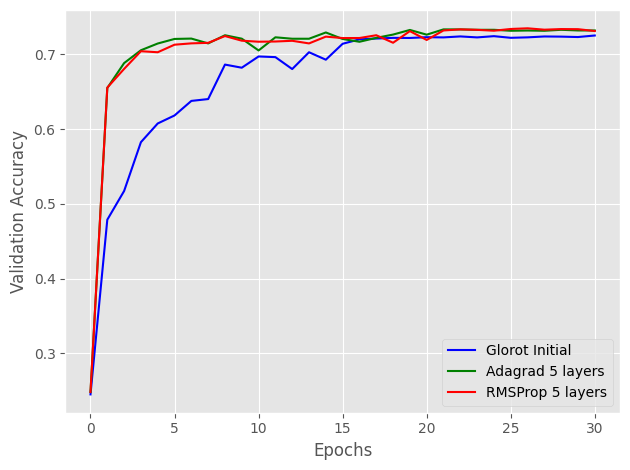

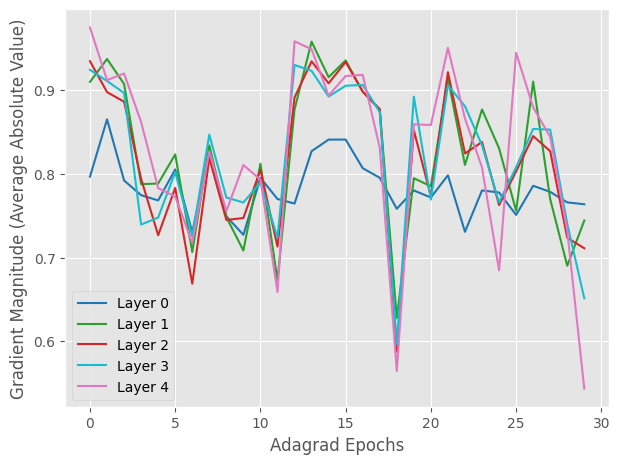

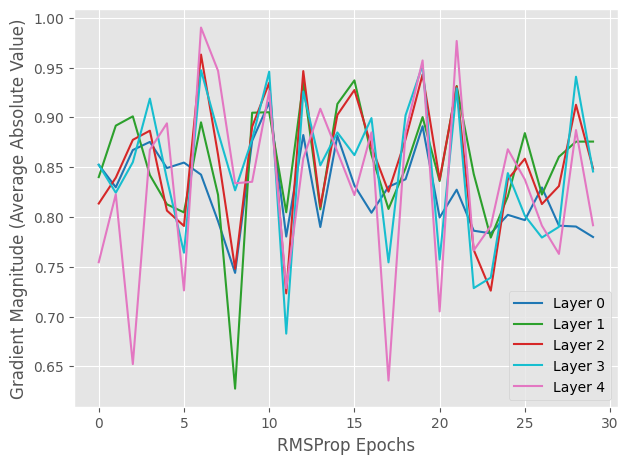

[[3202.  792.]
 [ 694. 9856.]]
χ² = 6.3318, p = 0.0118594360 for Glorot Initial and Adagrad so result is significantly different
[[3190.  804.]
 [ 717. 9833.]]
χ² = 4.8626, p = 0.0274450994 for Glorot Initial and RMSProp so result is significantly different
[[ 3446.   450.]
 [  461. 10187.]]
χ² = 0.1098, p = 0.7404067276 for Adagrad and RMSProp so result isn't significantly different


In [11]:
layer_count = 5
hidden_layer_count = layer_count - 1
vals = { 'n_hidden':[30] * hidden_layer_count,
        'C':0.1, 'epochs':30, 'eta':0.001,
        'alpha':0.001, 'decrease_const':0.1, 'decrease_iter':15,
        'minibatches':50,
        'shuffle':True,'random_state':1}

test_network = NLPBetterInitial(**vals)
%time test_network.fit(X_train, y_train, print_progress=1, XY_test=(X_test, y_test))
yhat_glorot = print_result(test_network,X_train,y_train,X_test,y_test,title="Glorot Initial",color="blue")

# Adagrad does worse if the same parameters are used, but tuning it helps
vals = {'n_hidden':[50] * hidden_layer_count, 
        'C':1e-2, 'epochs':30, 'eta':0.005, 
        'alpha':0.1, 'decrease_const':0.1,
        'decrease_iter':20,
        'minibatches':len(X_train)/256,
        'shuffle':True,'random_state':1}

nn_adagrad3 = NLPAdaGrad(**vals)
nn_rmsprop3 = NLPRMSProp(**vals)

%time nn_adagrad3.fit(X_train, y_train, print_progress=1, XY_test=(X_test, y_test))
yhat_adagrad = print_result(nn_adagrad3,X_train,y_train,X_test,y_test,title="Adagrad %d layers" % layer_count,color="green")

%time nn_rmsprop3.fit(X_train, y_train, print_progress=1, XY_test=(X_test, y_test))
yhat_rmsprop = print_result(nn_rmsprop3,X_train,y_train,X_test,y_test,title="RMSProp %d layers" % layer_count,color="red")

plt.show()

plot_gradient_magnitude(nn_adagrad3.grad_w_, "Adagrad")
plt.show()

plot_gradient_magnitude(nn_rmsprop3.grad_w_, "RMSProp")
plt.show()

test_models(y_test, 0.05, [yhat_glorot, yhat_adagrad, yhat_rmsprop], ["Glorot Initial", "Adagrad", "RMSProp"])

Here, we completed the last step of the project. We compared the performance of AdaGrad to our chosen adaptive learning technique RMSProp, and found that both models significantly outperformed Glorot initialization alone without the adaptive methods. There was not much of a difference between the two adaptive methods, even in performance with very similar CPU/wall clock times. If we had to choose between these three classifiers, we would choose the RMSProp classifier based on these parameters. However, the difference between Adagrad and RMSProp was statistically insignificant, and across runs, the method with the higher accuracy does flip, with a $p$ value tending to remain roughly in the 0.7-0.8 range. It may be possible that further fine-tuning might further improve accuracy to all of our models, but we believe gains would likely be very marginal and could unnecessarily add more risk of data snooping.